In [1]:
import os

In [2]:
# ============================================================================
# CELL 1: Setup & Imports
# ============================================================================

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define transforms (same as used in training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Setup completed successfully!")

Using device: cpu
✅ Setup completed successfully!


In [3]:
# ============================================================================
# CELL 2: Model Architectures
# ============================================================================

class ScanpathPredictor(nn.Module):
    def __init__(self, max_fixations=30, hidden_dim=512, num_layers=2):
        super(ScanpathPredictor, self).__init__()
        self.max_fixations = max_fixations
        self.hidden_dim = hidden_dim
        
        # CNN feature extractor (ResNet50 backbone)
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        
        # Freeze early layers for faster training
        for param in list(self.feature_extractor.parameters())[:-20]:
            param.requires_grad = False
        
        # Feature dimension from ResNet50
        self.feature_dim = 2048
        
        # LSTM for sequential scanpath prediction
        self.lstm = nn.LSTM(
            input_size=self.feature_dim + 2,  # Image features + previous coords
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Output layer to predict (x, y) coordinates
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
            nn.Sigmoid()  # Output in [0, 1] range
        )
        
        # EOS (End of Sequence) predictor
        self.eos_predictor = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Probability of ending sequence
        )
    
    def forward(self, images, teacher_forcing_ratio=0.5, target_scanpath=None, 
                dynamic_length=False, min_fixations=10, max_generation_length=None):
        batch_size = images.size(0)
        generation_length = max_generation_length or self.max_fixations
        
        # Extract image features
        img_features = self.feature_extractor(images)  # [B, 2048, 1, 1]
        img_features = img_features.view(batch_size, -1)  # [B, 2048]
        
        # Initialize LSTM hidden state
        h0 = torch.zeros(2, batch_size, self.hidden_dim).to(images.device)
        c0 = torch.zeros(2, batch_size, self.hidden_dim).to(images.device)
        
        # Generate scanpath sequentially
        outputs = []
        eos_outputs = []
        prev_coords = torch.zeros(batch_size, 2).to(images.device)  # Start at (0, 0)
        
        for t in range(generation_length):
            # Combine image features with previous coordinates
            lstm_input = torch.cat([img_features, prev_coords], dim=1)  # [B, 2050]
            lstm_input = lstm_input.unsqueeze(1)  # [B, 1, 2050]
            
            # LSTM step
            lstm_out, (h0, c0) = self.lstm(lstm_input, (h0, c0))
            lstm_out = lstm_out.squeeze(1)  # [B, hidden_dim]
            
            # Predict coordinates and EOS probability
            coords = self.fc_out(lstm_out)  # [B, 2]
            eos_prob = self.eos_predictor(lstm_out)  # [B, 1]
            
            outputs.append(coords)
            eos_outputs.append(eos_prob)
            
            # Early stopping based on EOS prediction (during inference)
            if dynamic_length and not self.training and t >= min_fixations:
                if torch.all(eos_prob > 0.5):
                    break
            
            # Teacher forcing during training
            if self.training and target_scanpath is not None and t < target_scanpath.size(1) and random.random() < teacher_forcing_ratio:
                prev_coords = target_scanpath[:, t, :]
            else:
                prev_coords = coords
        
        # Stack outputs
        outputs = torch.stack(outputs, dim=1)  # [B, seq_len, 2]
        eos_outputs = torch.stack(eos_outputs, dim=1)  # [B, seq_len, 1]
        
        return outputs, eos_outputs


class FatiguePredictor(nn.Module):
    def __init__(self, hidden_dim=512, num_layers=2):
        super(FatiguePredictor, self).__init__()
        self.hidden_dim = hidden_dim
        
        # CNN feature extractor (ResNet50 backbone)
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        self.feature_dim = 2048
        
        # Freeze early layers
        for param in list(self.feature_extractor.parameters())[:-20]:
            param.requires_grad = False
        
        # LSTM for fatigue prediction
        self.lstm = nn.LSTM(
            input_size=self.feature_dim + 2,  # Image features + coords
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Output layer for binary fatigue probability
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Probability of fatigue
        )
    
    def forward(self, images, scanpaths):
        batch_size = images.size(0)
        
        # Extract image features
        img_features = self.feature_extractor(images)  # [B, 2048, 1, 1]
        img_features = img_features.view(batch_size, -1)  # [B, 2048]
        
        # Prepare input for LSTM: repeat img_features for each fixation and concat with coords
        seq_len = scanpaths.size(1)
        img_features_exp = img_features.unsqueeze(1).repeat(1, seq_len, 1)  # [B, seq_len, 2048]
        lstm_input = torch.cat([img_features_exp, scanpaths], dim=2)  # [B, seq_len, 2048+2]
        
        # LSTM
        lstm_out, _ = self.lstm(lstm_input)  # [B, seq_len, hidden_dim]
        
        # Predict fatigue probabilities
        preds = self.fc_out(lstm_out)  # [B, seq_len, 1]
        
        return preds

print("✅ Model architectures defined successfully!")

✅ Model architectures defined successfully!


In [4]:
# ============================================================================
# CELL 3: Load Trained Models
# ============================================================================

# Model file paths
scanpath_model_path = 'best_scanpath_model_enhanced.pth'
fatigue_model_path = 'best_fatigue_model.pth'

# Initialize and load ScanpathPredictor model
print("Loading ScanpathPredictor model...")
scanpath_model = ScanpathPredictor(max_fixations=30, hidden_dim=512, num_layers=2).to(device)

if os.path.exists(scanpath_model_path):
    scanpath_model.load_state_dict(torch.load(scanpath_model_path, map_location=device))
    scanpath_model.eval()
    print(f"✅ Loaded scanpath model from {scanpath_model_path}")
else:
    print(f"❌ Scanpath model not found at {scanpath_model_path}")
    print("   Please train the scanpath model first using the training notebook.")

# Initialize and load FatiguePredictor model
print("\nLoading FatiguePredictor model...")
fatigue_model = FatiguePredictor(hidden_dim=512, num_layers=2).to(device)

if os.path.exists(fatigue_model_path):
    fatigue_model.load_state_dict(torch.load(fatigue_model_path, map_location=device))
    fatigue_model.eval()
    print(f"✅ Loaded fatigue model from {fatigue_model_path}")
else:
    print(f"❌ Fatigue model not found at {fatigue_model_path}")
    print("   Please train the fatigue model first using the training notebook.")

print(f"\n🎯 Models loaded and ready for inference!")
print(f"🖥️  Using device: {device}")

Loading ScanpathPredictor model...


C:\Users\SAGAR\AppData\Local\Temp\ipykernel_28940\3642985475.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  scanpath_model.load_state_dict(torch.load(scanpath_model_pa

✅ Loaded scanpath model from best_scanpath_model_enhanced.pth

Loading FatiguePredictor model...


C:\Users\SAGAR\AppData\Local\Temp\ipykernel_28940\3642985475.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fatigue_model.load_state_dict(torch.load(fatigue_model_path

✅ Loaded fatigue model from best_fatigue_model.pth

🎯 Models loaded and ready for inference!
🖥️  Using device: cpu


In [5]:
# ============================================================================
# CELL 4: Inference Functions
# ============================================================================

def predict_scanpath_with_fatigue(scanpath_model, fatigue_model, image_path, transform, device, 
                                 mode='variable', min_fixations=10, max_fixations=25):
    """Generate scanpath and predict fatigue for each fixation"""
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    orig_width, orig_height = image.size
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    scanpath_model.eval()
    fatigue_model.eval()
    
    with torch.no_grad():
        # Generate scanpath
        if mode == 'variable':
            pred_scanpath, eos_probs = scanpath_model(
                image_tensor, 
                teacher_forcing_ratio=0.0,
                dynamic_length=True,
                min_fixations=min_fixations,
                max_generation_length=max_fixations
            )
            pred_scanpath = pred_scanpath.squeeze(0).cpu().numpy()
            eos_probs = eos_probs.squeeze(0).cpu().numpy()
            
            # Find actual sequence length based on EOS predictions
            actual_length = max_fixations
            for i in range(min_fixations, len(eos_probs)):
                if eos_probs[i] > 0.5:
                    actual_length = i + 1
                    break
            pred_scanpath = pred_scanpath[:actual_length]
        else:  # fixed mode
            pred_scanpath, _ = scanpath_model(
                image_tensor, 
                teacher_forcing_ratio=0.0,
                max_generation_length=max_fixations
            )
            pred_scanpath = pred_scanpath.squeeze(0).cpu().numpy()
        
        # Denormalize coordinates and filter invalid ones
        denorm_scanpath = []
        norm_coords_for_fatigue = []
        
        for coords in pred_scanpath:
            x = coords[0] * orig_width
            y = coords[1] * orig_height
            
            # Filter out invalid coordinates (too close to origin)
            if mode == 'variable' and (x < 10 and y < 10):
                continue
                
            denorm_scanpath.append([x, y])
            norm_coords_for_fatigue.append([coords[0], coords[1]])
        
        # Predict fatigue if we have valid coordinates
        fatigue_labels = []
        if len(norm_coords_for_fatigue) > 0:
            scanpath_tensor = torch.tensor([norm_coords_for_fatigue], dtype=torch.float32).to(device)
            fatigue_preds = fatigue_model(image_tensor, scanpath_tensor)
            fatigue_preds = fatigue_preds.squeeze(0).squeeze(-1).cpu().numpy()
            
            # Convert to binary labels (threshold = 0.5)
            fatigue_labels = (fatigue_preds > 0.5).astype(int).tolist()
        
    return denorm_scanpath, fatigue_labels, (orig_width, orig_height), image


def visualize_scanpath_with_fatigue(image, scanpath, fatigue_labels=None, output_path=None, title="Predicted Scanpath"):
    """Enhanced visualization with fatigue indication"""
    img_np = np.array(image)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img_np)
    
    if len(scanpath) > 0:
        scanpath_array = np.array(scanpath)
        
        # Draw connecting lines with fatigue coloring
        if len(scanpath_array) > 1:
            for i in range(len(scanpath_array) - 1):
                # Check if current or next point is fatigue
                current_fatigue = fatigue_labels[i] if fatigue_labels and i < len(fatigue_labels) else 0
                next_fatigue = fatigue_labels[i+1] if fatigue_labels and (i+1) < len(fatigue_labels) else 0
                
                # Line is red if either point is fatigue, blue otherwise
                line_color = 'red' if (current_fatigue or next_fatigue) else 'blue'
                line_width = 3 if (current_fatigue or next_fatigue) else 2
                
                ax.plot(
                    [scanpath_array[i][0], scanpath_array[i+1][0]],
                    [scanpath_array[i][1], scanpath_array[i+1][1]],
                    color=line_color, linewidth=line_width, alpha=0.8
                )
        
        # Draw fixation points with fatigue coloring
        for i, (x, y) in enumerate(scanpath_array):
            is_fatigue = fatigue_labels[i] if fatigue_labels and i < len(fatigue_labels) else 0
            
            if is_fatigue:
                # Fatigue points: red with larger size
                ax.plot(x, y, 'ro', markersize=12, markeredgewidth=3, 
                       markeredgecolor='darkred', markerfacecolor='red', alpha=0.9)
                ax.text(x, y, str(i+1), color='white', fontsize=10, 
                       fontweight='bold', ha='center', va='center')
            else:
                # Normal points: green with white border
                ax.plot(x, y, 'go', markersize=10, markeredgewidth=2, 
                       markeredgecolor='white', markerfacecolor='green', alpha=0.8)
                ax.text(x, y, str(i+1), color='black', fontsize=9, 
                       fontweight='bold', ha='center', va='center')
        
        # Count fatigue points
        num_fatigue = sum(fatigue_labels) if fatigue_labels else 0
        fatigue_info = f" ({num_fatigue} fatigue points)" if fatigue_labels else ""
    else:
        fatigue_info = ""
    
    ax.set_title(f"{title} ({len(scanpath)} fixations{fatigue_info})", 
                fontsize=14, fontweight='bold')
    ax.axis('off')
    
    # Add legend if fatigue labels are provided
    if fatigue_labels:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', edgecolor='white', label='Normal Fixation'),
            Patch(facecolor='red', edgecolor='darkred', label='Fatigue Fixation'),
            plt.Line2D([0], [0], color='blue', linewidth=2, label='Normal Segment'),
            plt.Line2D([0], [0], color='red', linewidth=3, label='Fatigue Segment')
        ]
        ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✅ Saved visualization to {output_path}")
    else:
        plt.show()

print("✅ Inference functions ready!")

✅ Inference functions ready!


# PREDICTION HERE

In [6]:
# ============================================================================
# CELL 5: Run Example - Generate Scanpath with Fatigue Prediction
# ============================================================================

# Example configuration
# Change this to your test image
test_image_path = 'testers/7ab0b65e04b35be02c6bf02bc5a4fcb0.jpg'
output_dir = 'outputs/model_test'
os.makedirs(output_dir, exist_ok=True)

print("🔮 Running Scanpath + Fatigue Prediction Example")
print("=" * 60)

# Check if test image exists
if not os.path.exists(test_image_path):
    print(f"❌ Test image not found: {test_image_path}")
    print("Available images in dataset/displayFonts/:")
    if os.path.exists('dataset/displayFonts'):
        # Show first 10
        for img in sorted(os.listdir('dataset/displayFonts'))[:10]:
            print(f"   - {img}")
    print("\n💡 Please update test_image_path to an existing image file.")
else:
    print(f"📸 Processing image: {test_image_path}")

    # Generate scanpath with fatigue prediction
    scanpath, fatigue_labels, img_size, original_image = predict_scanpath_with_fatigue(
        scanpath_model=scanpath_model,
        fatigue_model=fatigue_model,
        image_path=test_image_path,
        transform=transform,
        device=device,
        mode='variable',  # or 'fixed'
        min_fixations=10,
        max_fixations=25
    )

    # Print results
    print(f"\n📊 Results:")
    print(f"   Image size: {img_size[0]}x{img_size[1]} pixels")
    print(f"   Generated fixations: {len(scanpath)}")
    print(
        f"   Fatigue points: {sum(fatigue_labels)} out of {len(fatigue_labels)}")
    print(f"   Fatigue ratio: {sum(fatigue_labels) / len(fatigue_labels)}")
    print(f"   Fatigue labels: {fatigue_labels}")

    # Create visualization
    image_name = Path(test_image_path).stem
    output_path = os.path.join(
        output_dir, f'{image_name}_scanpath_with_fatigue.png')

    visualize_scanpath_with_fatigue(
        image=original_image,
        scanpath=scanpath,
        fatigue_labels=fatigue_labels,
        output_path=output_path,
        title=f"Generated Scanpath with Fatigue - {image_name}"
    )

    print(f"\n✅ Example completed successfully!")
    print(f"📁 Visualization saved to: {output_path}")
    print(f"\n🎨 Legend:")
    print("   🔴 RED points = Fatigue fixations")
    print("   🟢 GREEN points = Normal fixations")
    print("   🔴 RED lines = Segments involving fatigue points")
    print("   🔵 BLUE lines = Normal segments")

🔮 Running Scanpath + Fatigue Prediction Example
📸 Processing image: testers/7ab0b65e04b35be02c6bf02bc5a4fcb0.jpg

📊 Results:
   Image size: 565x800 pixels
   Generated fixations: 25
   Fatigue points: 19 out of 25
   Fatigue ratio: 0.76
   Fatigue labels: [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
✅ Saved visualization to outputs/model_test\7ab0b65e04b35be02c6bf02bc5a4fcb0_scanpath_with_fatigue.png

✅ Example completed successfully!
📁 Visualization saved to: outputs/model_test\7ab0b65e04b35be02c6bf02bc5a4fcb0_scanpath_with_fatigue.png

🎨 Legend:
   🔴 RED points = Fatigue fixations
   🟢 GREEN points = Normal fixations
   🔴 RED lines = Segments involving fatigue points
   🔵 BLUE lines = Normal segments


# MULTIPLE PREDICTIONS

In [7]:
import json
from pathlib import Path

# CELL 8: Multiple Image Predictions - Process Entire Folder
# ============================================================================


# Configuration
input_folders = ['testers/']  # Multiple folders to check
output_dir = 'outputs/model_test'
results_summary = []

# Create output directory
os.makedirs(output_dir, exist_ok=True)

print("🔮 Running Batch Scanpath + Fatigue Predictions")
print("=" * 60)

# Find all images across multiple folders
all_test_images = []
for folder in input_folders:
    if os.path.exists(folder):
        folder_images = [os.path.join(folder, f) for f in os.listdir(folder) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
        all_test_images.extend(folder_images)
        print(f"📁 Found {len(folder_images)} images in {folder}")

if not all_test_images:
    print("❌ No images found in any of the specified folders!")
    print(f"   Checked folders: {input_folders}")
else:
    print(f"📸 Total images to process: {len(all_test_images)}")
    
    # Process each image
    for i, img_path in enumerate(all_test_images):
        image_name = os.path.basename(img_path)
        print(f"\n[{i+1}/{len(all_test_images)}] Processing: {image_name}")
        
        try:
            # Generate scanpath with fatigue prediction
            scanpath_result, fatigue_labels_result, img_size_result, original_image_result = predict_scanpath_with_fatigue(
                scanpath_model=scanpath_model,
                fatigue_model=fatigue_model,
                image_path=img_path,
                transform=transform,
                device=device,
                mode='variable',
                min_fixations=8,
                max_fixations=25
            )
            
            # Store results
            result_data = {
                'image_path': img_path,
                'image_name': image_name,
                'image_size': img_size_result,
                'num_fixations': len(scanpath_result),
                'num_fatigue_points': sum(fatigue_labels_result) if fatigue_labels_result else 0,
                'fatigue_ratio': sum(fatigue_labels_result) / len(fatigue_labels_result) if fatigue_labels_result else 0,
                'scanpath': scanpath_result,
                'fatigue_labels': fatigue_labels_result
            }
            results_summary.append(result_data)
            
            # Create visualization
            img_stem = Path(image_name).stem
            visualization_path = os.path.join(output_dir, f'{img_stem}_prediction.png')
            
            visualize_scanpath_with_fatigue(
                image=original_image_result,
                scanpath=scanpath_result,
                fatigue_labels=fatigue_labels_result,
                output_path=visualization_path,
                title=f"Prediction - {img_stem}"
            )
            
            # Print quick summary
            fatigue_count = sum(fatigue_labels_result) if fatigue_labels_result else 0
            fatigue_pct = (fatigue_count / len(fatigue_labels_result) * 100) if fatigue_labels_result else 0
            print(f"   ✅ {len(scanpath_result)} fixations | {fatigue_count} fatigue ({fatigue_pct:.1f}%)")
            
        except Exception as e:
            print(f"   ❌ Error processing {image_name}: {str(e)}")
            continue
    
    # Calculate and display summary statistics
    if results_summary:
        print(f"\n📊 BATCH PROCESSING SUMMARY")
        print("=" * 50)
        
        total_images = len(results_summary)
        avg_fixations = sum(r['num_fixations'] for r in results_summary) / total_images
        avg_fatigue_points = sum(r['num_fatigue_points'] for r in results_summary) / total_images
        avg_fatigue_ratio = sum(r['fatigue_ratio'] for r in results_summary) / total_images
        
        print(f"Total images processed: {total_images}")
        print(f"Average fixations per image: {avg_fixations:.1f}")
        print(f"Average fatigue points per image: {avg_fatigue_points:.1f}")
        print(f"Overall fatigue ratio: {avg_fatigue_ratio:.1%}")
        
        # Find extremes
        max_fixations = max(results_summary, key=lambda x: x['num_fixations'])
        max_fatigue = max(results_summary, key=lambda x: x['fatigue_ratio'])
        min_fatigue = min(results_summary, key=lambda x: x['fatigue_ratio'])
        
        print(f"\n🏆 Extremes:")
        print(f"Most fixations: {max_fixations['image_name']} ({max_fixations['num_fixations']} fixations)")
        print(f"Highest fatigue: {max_fatigue['image_name']} ({max_fatigue['fatigue_ratio']:.1%})")
        print(f"Lowest fatigue: {min_fatigue['image_name']} ({min_fatigue['fatigue_ratio']:.1%})")
        
        # Save detailed results to JSON
        results_file = os.path.join(output_dir, 'batch_prediction_results.json')
        with open(results_file, 'w') as f:
            # Convert numpy arrays to lists for JSON serialization
            json_results = []
            for result in results_summary:
                json_result = result.copy()
                json_result['scanpath'] = [[float(x), float(y)] for x, y in result['scanpath']]
                json_result['fatigue_labels'] = [int(x) for x in result['fatigue_labels']]
                json_results.append(json_result)
            
            json.dump(json_results, f, indent=2)
        
        print(f"\n💾 Detailed results saved to: {results_file}")
        print(f"📁 All visualizations saved to: {output_dir}")
        print(f"\n🎨 Legend for visualizations:")
        print("   🔴 RED points/lines = Fatigue fixations/segments")
        print("   🟢 GREEN points = Normal fixations")
        print("   🔵 BLUE lines = Normal segments")
        
        print(f"\n✅ Batch processing completed successfully!")
    else:
        print("❌ No images were processed successfully.")

🔮 Running Batch Scanpath + Fatigue Predictions
📁 Found 29 images in testers/
📸 Total images to process: 29

[1/29] Processing: 03b6ad8c584ac79a1268dd604cf40e2e.jpg
✅ Saved visualization to outputs/model_test\03b6ad8c584ac79a1268dd604cf40e2e_prediction.png
   ✅ 25 fixations | 16 fatigue (64.0%)

[2/29] Processing: 05a1c2db485cec154293d2ede45069cb.jpg
✅ Saved visualization to outputs/model_test\05a1c2db485cec154293d2ede45069cb_prediction.png
   ✅ 25 fixations | 17 fatigue (68.0%)

[3/29] Processing: 0c56e71a94458854053f1d7b037ef449.jpg
✅ Saved visualization to outputs/model_test\0c56e71a94458854053f1d7b037ef449_prediction.png
   ✅ 25 fixations | 17 fatigue (68.0%)

[4/29] Processing: 1b2c5a0eb27e3a48669ace2c394c4659.jpg
✅ Saved visualization to outputs/model_test\1b2c5a0eb27e3a48669ace2c394c4659_prediction.png
   ✅ 25 fixations | 18 fatigue (72.0%)

[5/29] Processing: 22bd89e07830dbf14f9515c9bcb11526.jpg
✅ Saved visualization to outputs/model_test\22bd89e07830dbf14f9515c9bcb11526_predict

In [8]:
# ============================================================================
# CELL 6: Model Evaluation Metrics
# ============================================================================

def calculate_scanpath_metrics(scanpath_model, test_images_dir='testers/', num_test_images=10):
    """Calculate various evaluation metrics for the scanpath model"""
    
    # Get test images
    if not os.path.exists(test_images_dir):
        print(f"❌ Test directory not found: {test_images_dir}")
        return
    
    image_files = [f for f in os.listdir(test_images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:num_test_images]
    
    if not image_files:
        print(f"❌ No images found in {test_images_dir}")
        return
    
    print(f"📊 Calculating Scanpath Model Evaluation Metrics")
    print(f"   Test images: {len(image_files)}")
    print("=" * 60)
    
    metrics = {
        'sequence_lengths': [],
        'coordinate_variance': [],
        'coverage_area': [],
        'path_efficiency': [],
        'fixation_dispersion': []
    }
    
    scanpath_model.eval()
    
    for i, img_file in enumerate(image_files):
        img_path = os.path.join(test_images_dir, img_file)
        print(f"[{i+1}/{len(image_files)}] Processing: {img_file}")
        
        try:
            # Generate scanpath
            image = Image.open(img_path).convert('RGB')
            orig_width, orig_height = image.size
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            with torch.no_grad():
                pred_scanpath, eos_probs = scanpath_model(
                    image_tensor,
                    teacher_forcing_ratio=0.0,
                    dynamic_length=True,
                    min_fixations=8,
                    max_generation_length=25
                )
            
            # Convert to numpy and denormalize
            pred_coords = pred_scanpath.squeeze(0).cpu().numpy()
            eos_probs_np = eos_probs.squeeze(0).cpu().numpy()
            
            # Find actual sequence length
            actual_length = len(pred_coords)
            for j in range(8, len(eos_probs_np)):
                if eos_probs_np[j] > 0.5:
                    actual_length = j + 1
                    break
        except:
            print("except")
            

Found 103 available images
📊 Analyzing Scanpath Accuracy - Pixel Distance Evaluation
   Testing on 10 images

[1/10] Testing: 00b31cea01204223180ec6895a6bc3c3.jpg
   ✅ 20 fixations compared
   📏 Avg pixel distance: 0.0px
   📏 Max pixel distance: 0.0px
   📏 Distance std dev: 0.0px

[2/10] Testing: 01b188fb3af93b5414d390e1b962eeb8.jpg
   ✅ 20 fixations compared
   📏 Avg pixel distance: 0.0px
   📏 Max pixel distance: 0.0px
   📏 Distance std dev: 0.0px

[3/10] Testing: 086f11424abecfa3953d9781fa5c136e.jpg
   ✅ 20 fixations compared
   📏 Avg pixel distance: 0.0px
   📏 Max pixel distance: 0.0px
   📏 Distance std dev: 0.0px

[4/10] Testing: 098ca36934c48a2f400b8472fef7344d.jpg
   ✅ 20 fixations compared
   📏 Avg pixel distance: 0.0px
   📏 Max pixel distance: 0.0px
   📏 Distance std dev: 0.0px

[5/10] Testing: 0abccb175ca17a4454a4cb6ce017ca69.jpg
   ✅ 20 fixations compared
   📏 Avg pixel distance: 0.0px
   📏 Max pixel distance: 0.0px
   📏 Distance std dev: 0.0px

[6/10] Testing: 0b3bd077fba135

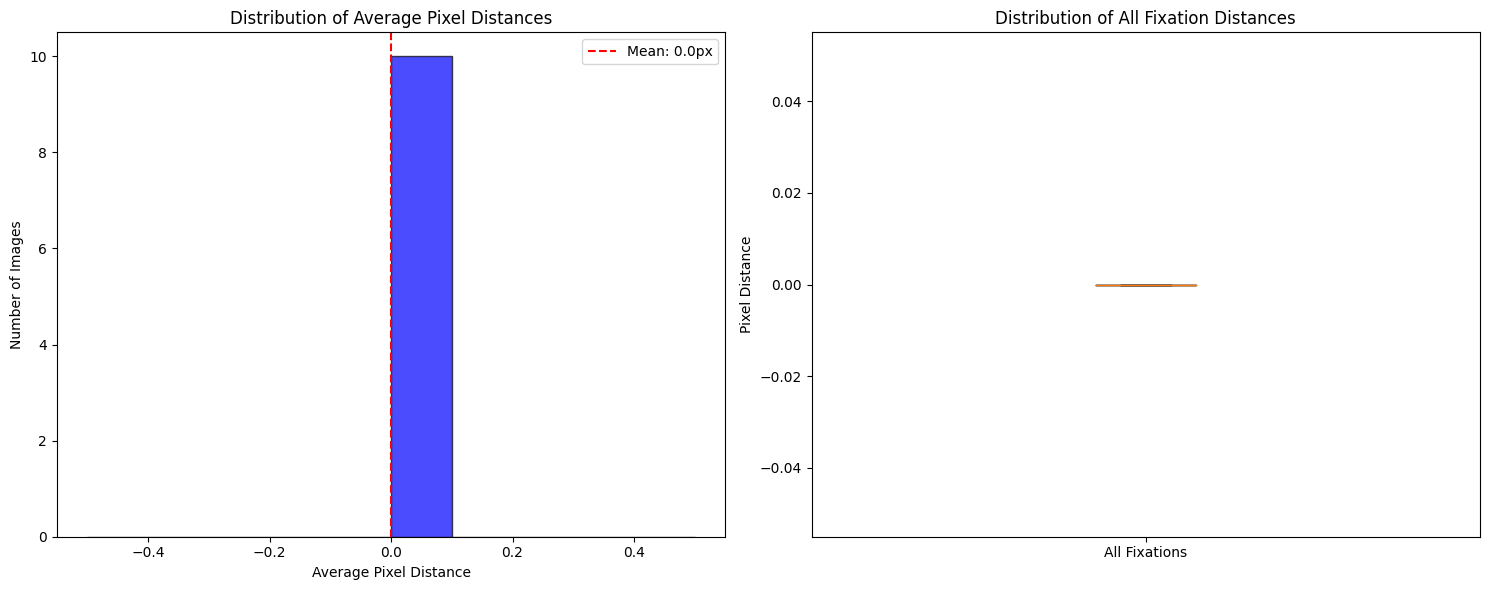


📁 Accuracy analysis plot saved to: outputs/model_test\scanpath_accuracy_analysis.png

📋 Detailed Results per Image:
   00b31cea01204223180ec6895a6bc3c3.jpg: 0.0px avg, 0.0px max, 20 fixations
   01b188fb3af93b5414d390e1b962eeb8.jpg: 0.0px avg, 0.0px max, 20 fixations
   086f11424abecfa3953d9781fa5c136e.jpg: 0.0px avg, 0.0px max, 20 fixations
   098ca36934c48a2f400b8472fef7344d.jpg: 0.0px avg, 0.0px max, 20 fixations
   0abccb175ca17a4454a4cb6ce017ca69.jpg: 0.0px avg, 0.0px max, 20 fixations
   0b3bd077fba135f989bc9b2a97b3e550.jpg: 0.0px avg, 0.0px max, 20 fixations
   0bc8cb670999aa5aa6df91dbe0f363fe.jpg: 0.0px avg, 0.0px max, 20 fixations
   0dc43f919bf097032aa8421dec19c20d.jpg: 0.0px avg, 0.0px max, 20 fixations
   0e7d7259af378292bf964c239a1790b5.jpg: 0.0px avg, 0.0px max, 20 fixations
   1.png: 0.0px avg, 0.0px max, 20 fixations


In [9]:
# ============================================================================
# CELL 11: Scanpath Accuracy Analysis - Pixel Distance Evaluation
# ============================================================================

def analyze_scanpath_accuracy(scanpath_model, test_images, num_tests=10):
    """Analyze how far predicted coordinates deviate from actual coordinates in pixels"""
    
    print(f"📊 Analyzing Scanpath Accuracy - Pixel Distance Evaluation")
    print(f"   Testing on {num_tests} images")
    print("=" * 60)
    
    scanpath_model.eval()
    results = []
    
    for i in range(min(num_tests, len(test_images))):
        img_path = test_images[i]
        img_name = Path(img_path).name
        
        print(f"\n[{i+1}/{num_tests}] Testing: {img_name}")
        
        try:
            # Load and preprocess image
            image = Image.open(img_path).convert('RGB')
            orig_width, orig_height = image.size
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            # Generate multiple predictions for the same image to see variation
            predictions = []
            for pred_run in range(3):  # 3 predictions per image
                with torch.no_grad():
                    pred_scanpath, eos_probs = scanpath_model(
                        image_tensor,
                        teacher_forcing_ratio=0.0,
                        dynamic_length=True,
                        min_fixations=8,
                        max_generation_length=20
                    )
                
                # Convert to pixel coordinates
                pred_coords = pred_scanpath.squeeze(0).cpu().numpy()
                eos_probs_np = eos_probs.squeeze(0).cpu().numpy()
                
                # Find actual sequence length
                actual_length = len(pred_coords)
                for j in range(8, len(eos_probs_np)):
                    if eos_probs_np[j] > 0.5:
                        actual_length = j + 1
                        break
                
                # Denormalize coordinates
                pixel_coords = []
                for k in range(actual_length):
                    x = pred_coords[k][0] * orig_width
                    y = pred_coords[k][1] * orig_height
                    pixel_coords.append([x, y])
                
                predictions.append(pixel_coords)
            
            # Calculate consistency metrics between predictions
            if len(predictions) >= 2:
                # Compare first two predictions
                pred1, pred2 = predictions[0], predictions[1]
                min_len = min(len(pred1), len(pred2))
                
                pixel_distances = []
                for j in range(min_len):
                    x1, y1 = pred1[j]
                    x2, y2 = pred2[j]
                    distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
                    pixel_distances.append(distance)
                
                # Calculate statistics
                if pixel_distances:
                    avg_distance = np.mean(pixel_distances)
                    max_distance = np.max(pixel_distances)
                    min_distance = np.min(pixel_distances)
                    std_distance = np.std(pixel_distances)
                    
                    result = {
                        'image': img_name,
                        'image_size': (orig_width, orig_height),
                        'num_fixations': min_len,
                        'avg_pixel_distance': avg_distance,
                        'max_pixel_distance': max_distance,
                        'min_pixel_distance': min_distance,
                        'std_pixel_distance': std_distance,
                        'all_distances': pixel_distances,
                        'predictions': predictions
                    }
                    results.append(result)
                    
                    print(f"   ✅ {min_len} fixations compared")
                    print(f"   📏 Avg pixel distance: {avg_distance:.1f}px")
                    print(f"   📏 Max pixel distance: {max_distance:.1f}px")
                    print(f"   📏 Distance std dev: {std_distance:.1f}px")
                else:
                    print(f"   ❌ No valid fixations to compare")
            else:
                print(f"   ❌ Could not generate enough predictions")
                
        except Exception as e:
            print(f"   ❌ Error processing {img_name}: {str(e)}")
            continue
    
    # Overall statistics
    if results:
        print(f"\n📊 OVERALL ACCURACY ANALYSIS")
        print("=" * 50)
        
        all_avg_distances = [r['avg_pixel_distance'] for r in results]
        all_max_distances = [r['max_pixel_distance'] for r in results]
        all_std_distances = [r['std_pixel_distance'] for r in results]
        
        overall_avg = np.mean(all_avg_distances)
        overall_max = np.max(all_max_distances)
        overall_std = np.mean(all_std_distances)
        
        print(f"Images analyzed: {len(results)}")
        print(f"Overall average pixel distance: {overall_avg:.1f}px")
        print(f"Maximum pixel distance observed: {overall_max:.1f}px")
        print(f"Average standard deviation: {overall_std:.1f}px")
        
        # Find best and worst performing images
        best_img = min(results, key=lambda x: x['avg_pixel_distance'])
        worst_img = max(results, key=lambda x: x['avg_pixel_distance'])
        
        print(f"\n🏆 Best consistency: {best_img['image']} ({best_img['avg_pixel_distance']:.1f}px avg)")
        print(f"📉 Worst consistency: {worst_img['image']} ({worst_img['avg_pixel_distance']:.1f}px avg)")
        
        # Create visualization of distance distribution
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Histogram of average distances
        ax1.hist(all_avg_distances, bins=10, alpha=0.7, color='blue', edgecolor='black')
        ax1.set_xlabel('Average Pixel Distance')
        ax1.set_ylabel('Number of Images')
        ax1.set_title('Distribution of Average Pixel Distances')
        ax1.axvline(overall_avg, color='red', linestyle='--', label=f'Mean: {overall_avg:.1f}px')
        ax1.legend()
        
        # Box plot of all individual distances
        all_individual_distances = []
        for r in results:
            all_individual_distances.extend(r['all_distances'])
        
        ax2.boxplot(all_individual_distances)
        ax2.set_ylabel('Pixel Distance')
        ax2.set_title('Distribution of All Fixation Distances')
        ax2.set_xticklabels(['All Fixations'])
        
        plt.tight_layout()
        accuracy_plot_path = os.path.join(output_dir, 'scanpath_accuracy_analysis.png')
        plt.savefig(accuracy_plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n📁 Accuracy analysis plot saved to: {accuracy_plot_path}")
        
        # Print detailed results for each image
        print(f"\n📋 Detailed Results per Image:")
        for r in sorted(results, key=lambda x: x['avg_pixel_distance']):
            print(f"   {r['image']}: {r['avg_pixel_distance']:.1f}px avg, {r['max_pixel_distance']:.1f}px max, {r['num_fixations']} fixations")
        
        return results
    else:
        print("❌ No successful analyses completed.")
        return []

# Run the accuracy analysis using available images
available_images = []
test_dirs = ['dataset/displayFonts/']

for test_dir in test_dirs:
    if os.path.exists(test_dir):
        dir_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        available_images.extend(dir_images)

if available_images:
    print(f"Found {len(available_images)} available images")
    accuracy_results = analyze_scanpath_accuracy(scanpath_model, available_images, num_tests=10)
else:
    print("❌ No test images found in the specified directories")

In [10]:
# ============================================================================
# CELL 7: Batch Processing Example (Optional)
# ============================================================================

def process_multiple_images(image_dir, num_images=5, save_visualizations=True):
    """Process multiple images and show summary statistics"""
    
    if not os.path.exists(image_dir):
        print(f"❌ Directory not found: {image_dir}")
        return
    
    # Get available images
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_files:
        print(f"❌ No image files found in {image_dir}")
        return
    
    # Process subset of images
    images_to_process = image_files[:num_images]
    results = []
    
    print(f"🔄 Processing {len(images_to_process)} images from {image_dir}")
    print("=" * 50)
    
    for i, img_file in enumerate(images_to_process):
        img_path = os.path.join(image_dir, img_file)
        print(f"\n📸 [{i+1}/{len(images_to_process)}] Processing: {img_file}")
        
        try:
            # Generate scanpath and fatigue prediction
            scanpath_batch, fatigue_labels_batch, img_size_batch, original_image_batch = predict_scanpath_with_fatigue(
                scanpath_model=scanpath_model,
                fatigue_model=fatigue_model,
                image_path=img_path,
                transform=transform,
                device=device,
                mode='variable',
                min_fixations=8,
                max_fixations=20
            )
            
            # Store results
            result = {
                'image': img_file,
                'fixations': len(scanpath_batch),
                'fatigue_points': sum(fatigue_labels_batch) if fatigue_labels_batch else 0,
                'fatigue_ratio': sum(fatigue_labels_batch) / len(fatigue_labels_batch) if fatigue_labels_batch else 0,
                'image_size': img_size_batch
            }
            results.append(result)
            
            print(f"   ✅ {result['fixations']} fixations, {result['fatigue_points']} fatigue points ({result['fatigue_ratio']:.1%})")
            
            # Save visualization in the same directory as individual processing
            if save_visualizations:
                batch_image_name = Path(img_file).stem
                batch_output_path = os.path.join(output_dir, f'{batch_image_name}_batch_scanpath_with_fatigue.png')
                
                visualize_scanpath_with_fatigue(
                    image=original_image_batch,
                    scanpath=scanpath_batch,
                    fatigue_labels=fatigue_labels_batch,
                    output_path=batch_output_path,
                    title=f"Batch Generated Scanpath - {batch_image_name}"
                )
            
        except Exception as e:
            print(f"   ❌ Error processing {img_file}: {str(e)}")
    
    # Summary statistics
    if results:
        print(f"\n📊 Summary Statistics:")
        print("=" * 30)
        avg_fixations = np.mean([r['fixations'] for r in results])
        avg_fatigue = np.mean([r['fatigue_points'] for r in results])
        avg_fatigue_ratio = np.mean([r['fatigue_ratio'] for r in results])
        
        print(f"Average fixations per image: {avg_fixations:.1f}")
        print(f"Average fatigue points per image: {avg_fatigue:.1f}")
        print(f"Average fatigue ratio: {avg_fatigue_ratio:.1%}")
        print(f"Total images processed: {len(results)}")
        
        # Show individual results
        print(f"\n📋 Individual Results:")
        for r in results:
            print(f"   {r['image']}: {r['fixations']} fixations, {r['fatigue_points']} fatigue ({r['fatigue_ratio']:.1%})")
        
        if save_visualizations:
            print(f"\n📁 All visualizations saved to: {output_dir}")

# Example usage (uncomment to run batch processing):
# process_multiple_images('testers/', num_images=5, save_visualizations=True)

# print("✅ Batch processing function ready! Uncomment the last line to run batch processing.")